# Extract model parameter(natural frequency and modal shape) into np file.

In [1]:
from sdypy import EMA
import numpy as np
import matplotlib.pyplot as plt

import os

# Update these paths to match your Python 3.13 installation location
tcl_path = r"C:\Program Files\Python313\tcl\tcl8.6"
tk_path = r"C:\Program Files\Python313\tcl\tk8.6"

os.environ['TCL_LIBRARY'] = tcl_path
os.environ['TK_LIBRARY'] = tk_path

# START

In [505]:
class_name = '(T)HD_E4_T00_R3'
#frf = np.load(rf"D:\UM Document\FYP_ML\450,60,2 Dataset\processed_dataset2\frf_{class_name}.npy")[10, :]
frf = np.load(rF"D:\UM Document\FYP_ML\450,60,2 Dataset\Frf_3\frf_{class_name}.npy")[19, :]
#frf = np.load(rf"D:\UM Document\FYP_ML\frf_{class_name}.npy")[10, :]
freq = np.linspace(0, 1024, 2049)

(0.0, 200.0)

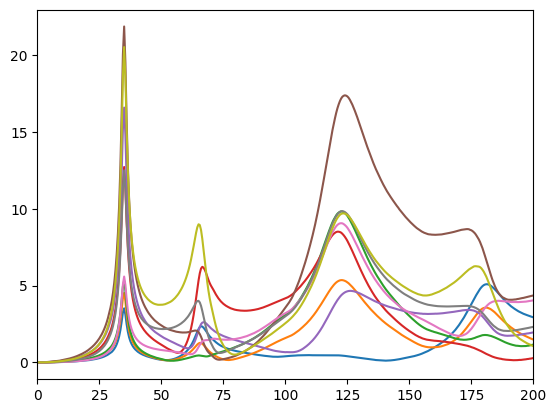

In [506]:
plt.plot(freq, np.abs(frf.T))
plt.xlim(0, 200)

In [507]:
acc = EMA.Model(frf=frf,
                freq=freq,
                lower=10,
                upper=200,
                pol_order_high=80)

In [508]:
acc.get_poles(method='lscf')
acc.select_poles()

100%|██████████████████████████████████████████████████████████████| 80/80 [00:00<00:00, 218.81it/s]


<Figure size 640x480 with 0 Axes>

In [509]:
# n_freq =  [43.14,109.87,151.21]

# UD: Undamaged Reference
# Mean Calculation: [(44.6+45.2+45.2)/3, (109.9+109.9+109.9)/3, (151.6+151.6+151.5)/3]
# n_freq = [45.0, 109.9, 151.6] # UD Group Final

# # LD: Light Damage 
# n_freq = [43.4, 109.3, 151.5] # LD_E1 Group Final
# n_freq = [43.4, 109.5, 151.4] # LD_E2 Group Final
# n_freq = [42.9, 109.2, 151.3] # LD_E3 Group Final
# n_freq = [42.7, 109.1, 150.5] # LD_E4 Group Final

# # MD: Medium Damage
# n_freq = [41.2, 107.0, 146.9] # MD_E1 Group Final
# n_freq = [42.1, 107.3, 147.7] # MD_E2 Group Final
# n_freq = [41.3, 107.6, 147.4] # MD_E3 Group Final
# n_freq = [41.1, 107.4, 147.3] # MD_E4 Group Final

# # HD: Heavy Damage (Note: Modal density increases significantly here)
# n_freq = [39.3, 83.7, 124.6]  # HD_E1 Group Final

# # HD_E2 exhibits high modal splitting/coupling
# n_freq = [36.5, 71.2, 81.4, 115.5, 131.8, 152.4] #, 168.6, 177.8, 185.1, 189.1] # HD_E2 Group Final

# # HD_E3
# n_freq = [38.0, 77.6, 115.5, 146.9, 192.2] # HD_E3 Group Final

# # HD_E4
# n_freq = [40.6, 113.3, 146.7, 172.0] # HD_E4 Group Final

#acc.select_closest_poles(n_freq)

In [510]:
frf_rec, modal_const = acc.get_constants(whose_poles='own', FRF_ind='all', upper_r=False)

In [511]:
acc.print_modal_data()

   Nat. f.      Damping
-----------------------
1)   34.9	0.0305
2)   65.9	0.0456
3)  122.8	0.0811
4)  180.2	0.0437


In [512]:
acc.A

array([[ 7.90318873e-06-4.90996038e-04j, -2.10140510e-05-2.43861579e-04j,
        -3.29923092e-05-1.85573977e-05j, -3.47968444e-05-1.94791034e-04j],
       [-7.72940882e-07-5.96924165e-04j, -2.83473024e-05-8.60624202e-05j,
         2.28007056e-05-5.00720394e-04j,  1.86001345e-05-1.07155017e-04j],
       [-1.12407255e-05-6.82535063e-04j, -3.33389839e-05+5.51203946e-05j,
         6.33648743e-05-9.24877536e-04j,  5.83765767e-05-1.28056574e-05j],
       [ 8.47531094e-05-1.78204485e-03j,  1.69937068e-05-6.24694982e-04j,
        -6.54843181e-05+8.50232366e-04j, -6.64416583e-06-1.82261417e-05j],
       [ 3.16884467e-05-2.32894889e-03j, -3.49634720e-05-2.11336884e-04j,
        -1.93778885e-05-4.23489057e-04j, -1.15239918e-06+6.98483363e-05j],
       [-2.41597620e-05-3.08428994e-03j, -9.33290634e-05+1.56268895e-04j,
         7.75427969e-06-1.79760708e-03j, -2.29588291e-06+1.75459620e-04j],
       [ 7.00929356e-05-7.64606606e-04j,  5.19067875e-05-7.97971620e-05j,
         1.57229709e-04+9.809385

In [513]:
acc.nat_freq

[np.float64(34.85025474534107),
 np.float64(65.87392310524685),
 np.float64(122.76383770961935),
 np.float64(180.1591108910767)]

In [514]:
acc.nat_xi

[np.float64(0.030451414024702084),
 np.float64(0.045577124961113116),
 np.float64(0.08113338706061816),
 np.float64(0.04373466388838813)]

In [515]:
# column 0 is the natural frequency, column 1 is the damping ratio, columns 2... are mode shapes
modal_parameters = np.c_[np.array(acc.nat_freq).reshape(-1), np.array(acc.nat_xi).reshape(-1), acc.A.transpose()]

In [516]:
# save modal parameters to npy file
with open(f"Modal Parameter Extracted NPY3\\Modalparameters_{class_name}.npy", "wb") as f:
    np.save(f, modal_parameters)

print("Modal parameters saved to npy file successfully.")

Modal parameters saved to npy file successfully.
